In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('jj.csv')
df

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61
...,...,...
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02


In [2]:
train = df[:-4]
test = df[-4:]

test

,date,data
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


In [3]:
historical_mean = np.mean(train['data'])
historical_mean

np.float64(4.308499987499999)

In [4]:
test.loc[:, 'pred_mean'] = historical_mean

In [6]:
test

,date,data,pred_mean
80,1980-01-01,16.20,4.3085
81,1980-04-01,14.67,4.3085
82,1980-07-02,16.02,4.3085
83,1980-10-01,11.61,4.3085


In [25]:
#error = test['data'] - test['pred_mean']

#np.abs(error / test['data'])

In [24]:

#es el mean de los porcentajes
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape(test['data'],test['pred_mean'])

np.float64(70.00752579965119)

In [38]:
np.arange(0,85,8)

array([ 0,  8, 16, 24, 32, 40, 48, 56, 64, 72, 80])

([<matplotlib.axis.XTick at 0x7928654f8050>,
 [Text(0, 0, '1960'),
  Text(8, 0, '1962'),
  Text(16, 0, '1964'),
  Text(24, 0, '1966'),
  Text(32, 0, '1968'),
  Text(40, 0, '1970'),
  Text(48, 0, '1972'),
  Text(56, 0, '1974'),
  Text(64, 0, '1976'),
  Text(72, 0, '1978'),
  Text(80, 0, '1980')])

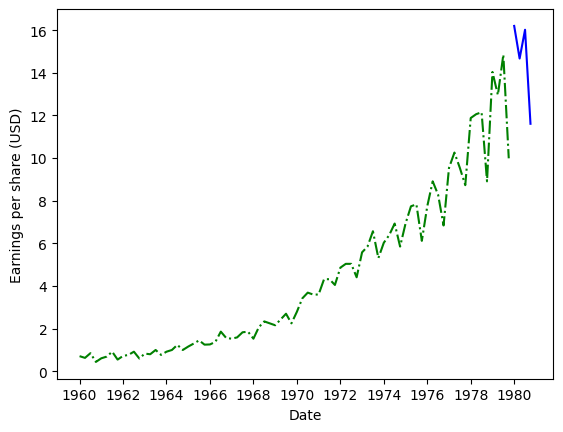

In [45]:
fig,ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')

ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')

#'son indices'
plt.xticks(np.arange(0,85,8), labels=[1960,1962,1964,1966,1968,1970,1972,1974,1976,1978,1980])